# Getting Started with galpy

This tutorial introduces the most basic features of galpy: setting up gravitational potentials,
plotting rotation curves, understanding galpy's unit system, and integrating orbits.

galpy's two core modules are `galpy.potential` (gravitational potentials) and `galpy.orbit` (orbit integration).

<div class="alert alert-info">

**Tip**

You can copy all of the code examples in this documentation to your clipboard by clicking the clipboard button in the top-right corner of each code cell.

</div>

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## 1. Rotation Curves

### A single disk potential

Let's start by initializing a Miyamoto-Nagai disk potential and plotting its rotation curve.
The `normalize=1.` option normalizes the potential so that the circular velocity equals 1 at R=1
(in galpy's natural units).

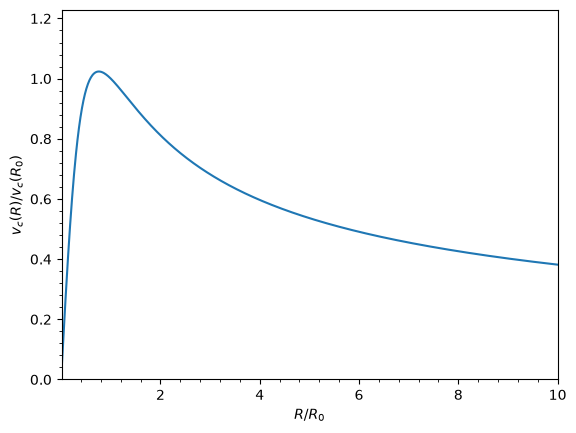

In [2]:
from galpy.potential import MiyamotoNagaiPotential

mp = MiyamotoNagaiPotential(a=0.5, b=0.0375, normalize=1.0)
mp.plotRotcurve(Rrange=[0.01, 10.0], grid=1001);

### Combining multiple potentials

A realistic galaxy model requires multiple components. We can combine potentials simply by
adding them with `+`. Here we create a three-component model with a disk, a halo, and a bulge.
Note that the `normalize` values sum to 1, so the composite circular velocity is 1 at R=1.

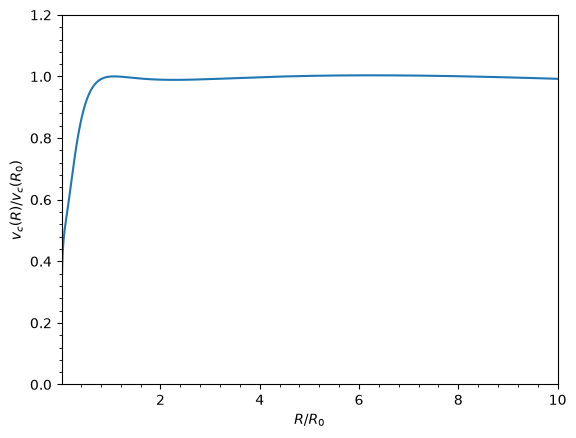

In [3]:
from galpy.potential import NFWPotential, HernquistPotential

mp = MiyamotoNagaiPotential(a=0.5, b=0.0375, normalize=0.6)
nfp = NFWPotential(a=4.5, normalize=0.35)
hp = HernquistPotential(a=0.6 / 8, normalize=0.05)
(hp + mp + nfp).plotRotcurve(Rrange=[0.01, 10.0], grid=1001, yrange=[0.0, 1.2]);

The resulting rotation curve is approximately flat, as observed in many spiral galaxies.
We can overplot the individual component curves to see how each contributes:

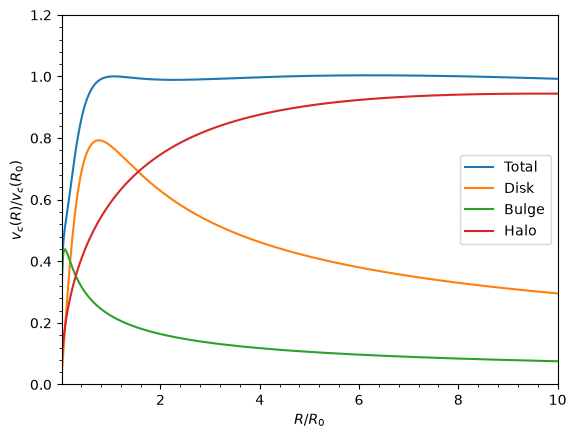

In [4]:
(hp + mp + nfp).plotRotcurve(
    Rrange=[0.01, 10.0], grid=1001, yrange=[0.0, 1.2], label="Total"
)
mp.plotRotcurve(Rrange=[0.01, 10.0], grid=1001, overplot=True, label="Disk")
hp.plotRotcurve(Rrange=[0.01, 10.0], grid=1001, overplot=True, label="Bulge")
nfp.plotRotcurve(Rrange=[0.01, 10.0], grid=1001, overplot=True, label="Halo")
plt.legend();

### MWPotential2014

galpy includes `MWPotential2014`, a Milky-Way-like potential fit to
various dynamical constraints ([Bovy 2015](http://arxiv.org/abs/1412.3451)). See the [Introduction to Potentials](../potentials/introduction.ipynb) for details.

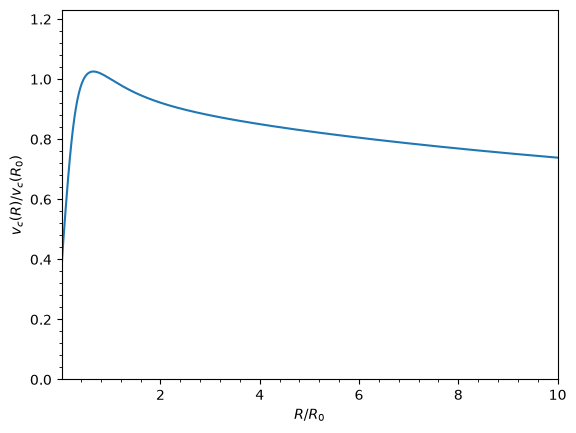

In [5]:
from galpy.potential import MWPotential2014

MWPotential2014.plotRotcurve(Rrange=[0.01, 10.0], grid=1001);

## 2. Natural Units

Internally, galpy uses a **natural unit system**, where:

- Positions are scaled as $x = X / $ ro
- Velocities are scaled as $v = V / $ vo,

where the default values of `ro` and `vo` are 8 kpc and 220 km/s, respectively. These can be changed when initializing potentials, orbits, or other galpy objects or they can be changed in the [configuration file](../../installation.rst#configuration-file). So when `normalize=1.` is set, the circular velocity is 1 at R=1, which corresponds to 220 km/s at 8 kpc for a Milky-Way-like galaxy.

The `galpy.util.conversion` module helps convert between natural and physical units.
For example, the orbital period of a circular orbit at R=1 is $2\pi$ in natural units.
In physical units:

In [6]:
from galpy.util import conversion

print(
    "Orbital period at R=1:", 2.0 * numpy.pi * conversion.time_in_Gyr(220.0, 8.0), "Gyr"
)

Orbital period at R=1: 0.22340544439051707 Gyr


About 223 Myr, as expected for a solar-like orbit.

We can also convert forces and densities. For example, the vertical force at
1.1 kpc above the plane at the solar radius in `MWPotential2014`:

In [7]:
Fz = -MWPotential2014.zforce(1.0, 1.1 / 8.0)
print("Fz in pc/Myr^2:", Fz * conversion.force_in_pcMyr2(220.0, 8.0))
print("Fz in 2*pi*G*Msun/pc^2:", Fz * conversion.force_in_2piGmsolpc2(220.0, 8.0))

Fz in pc/Myr^2: 2.0259181889046634
Fz in 2*pi*G*Msun/pc^2: 71.67605643105574


The `conversion` module also has functions for densities (`dens_in_msolpc3`),
masses (`mass_in_msol`), surface densities, and frequencies.
See the [API documentation](../../reference/potential.rst) for a full list.

## 3. Physical Units with astropy

Any input to a galpy Potential, Orbit, or other object can be specified in physical units
using astropy Quantities. For example, we can set up a Miyamoto-Nagai potential with
a mass of $5 \times 10^{10}\,M_\odot$, a scale length of 3 kpc, and a scale height of 300 pc:

In [8]:
from astropy import units

mp_phys = MiyamotoNagaiPotential(
    amp=5e10 * units.Msun, a=3.0 * units.kpc, b=300.0 * units.pc
)

When a potential is set up with physical-unit inputs, outputs are returned in physical units
by default. The circular velocity at 10 kpc:

In [9]:
print("v_circ at 10 kpc:", mp_phys.vcirc(10.0 * units.kpc), "km/s")

v_circ at 10 kpc: 135.70512798497137 km/s


If you have `astropy-units = True` in your galpy configuration file, the return value
will be an astropy Quantity with units attached. Without that setting, the value is
returned as a plain float in the default units (km/s for velocities, kpc for distances, etc.).

<div class="alert alert-warning">

**Warning**

If you do not specify arguments as a Quantity, galpy assumes they are in natural units.
For example, `mp_phys.vcirc(10.)` treats the input as 10 times the distance scale (80 kpc by default),
not 10 kpc.

</div>

### Default physical units

When outputs are returned in physical units, the following default units are used:

| Quantity | Default unit |
|----------|-------------|
| position | kpc |
| velocity | km/s |
| angular velocity | km/s/kpc |
| energy | (km/s)^2 |
| angular momentum | km/s x kpc |
| actions | km/s x kpc |
| frequencies | 1/Gyr |
| time | Gyr |
| period | Gyr |
| potential | (km/s)^2 |
| force | km/s/Myr |
| density | Msun/pc^3 |
| surface density | Msun/pc^2 |
| mass | Msun |
| proper motion | mas/yr |

<div class="alert alert-warning">

**Warning**

When returned as a `Quantity`, frequencies get units of 1/Gyr, although in detail this means rad/Gyr (not cycles/Gyr).

</div>

<div class="alert alert-info">

**Tip**

When you specify all inputs as astropy Quantities with units and receive outputs as Quantities, the internal unit-conversion parameters `ro` and `vo` are irrelevant -- you do not need to set them.

</div>

### Toggling physical units on and off

You can toggle physical-unit output on or off for an object, or override it per call
using the `use_physical` keyword. You can also pass `quantity=True` to any evaluation to get the result as an astropy `Quantity`.

In [10]:
mp_phys.turn_physical_off()
print("Natural units:", mp_phys.vcirc(1.0))
mp_phys.turn_physical_on()
print("Physical units:", mp_phys.vcirc(1.0), "km/s")
# Per-call overrides:
print(
    "Per-call override of use_physical:",
    mp_phys.vcirc(10.0 * units.kpc, use_physical=False),
)
print("Per-call override of quantity:", mp_phys.vcirc(10.0 * units.kpc, quantity=True))

Natural units: 0.6623918492376609
Physical units: 145.7262068322854 km/s
Per-call override of use_physical: 0.616841490840779
Per-call override of quantity: 135.70512798497137 km / s


## 4. First Orbit Integration

Let's integrate an orbit in the Miyamoto-Nagai potential. We initialize an orbit
with a five-dimensional initial condition `[R, vR, vT, z, vz]` (axisymmetric, so no azimuth):

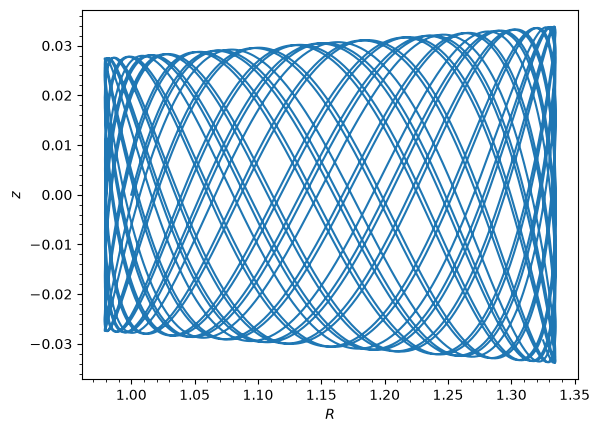

In [11]:
from galpy.orbit import Orbit

mp = MiyamotoNagaiPotential(a=0.5, b=0.0375, amp=1.0, normalize=1.0)
o = Orbit([1.0, 0.1, 1.1, 0.0, 0.1])
ts = numpy.linspace(0, 100, 10000)
o.integrate(ts, mp)
o.plot();

The orbit plot shows R vs. z. We can check energy conservation:

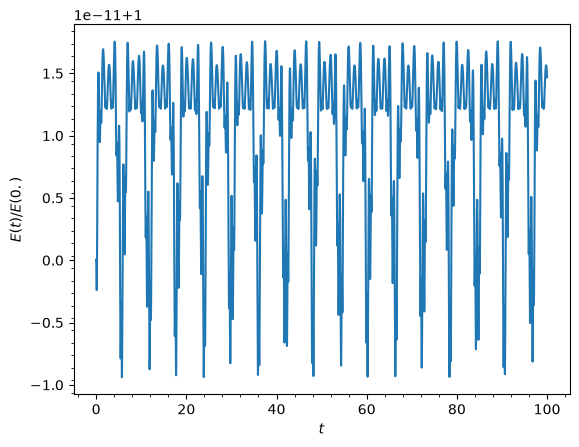

In [12]:
o.plotE(normed=True);

Energy is well conserved. See the [Orbit Integration and Plotting](../orbits/integration_and_plotting.ipynb) tutorial for more on integrators and energy conservation.

We can also integrate in the composite potential defined earlier:

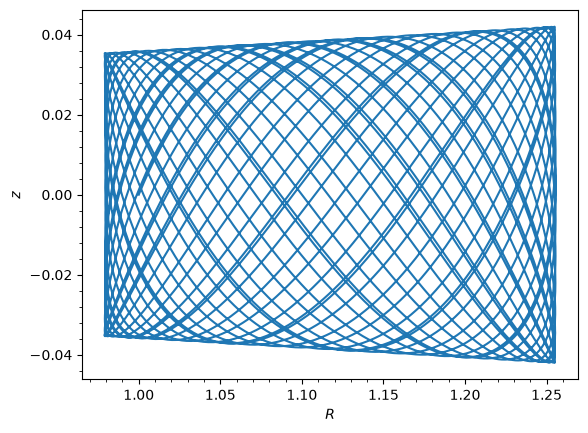

In [13]:
mp = MiyamotoNagaiPotential(a=0.5, b=0.0375, normalize=0.6)
nfp = NFWPotential(a=4.5, normalize=0.35)
hp = HernquistPotential(a=0.6 / 8, normalize=0.05)
o = Orbit([1.0, 0.1, 1.1, 0.0, 0.1])
ts = numpy.linspace(0, 100, 10000)
o.integrate(ts, mp + hp + nfp)
o.plot();

## 5. Escape Velocity Curves

Just like rotation curves, we can plot escape velocity curves for any potential or
combination of potentials:

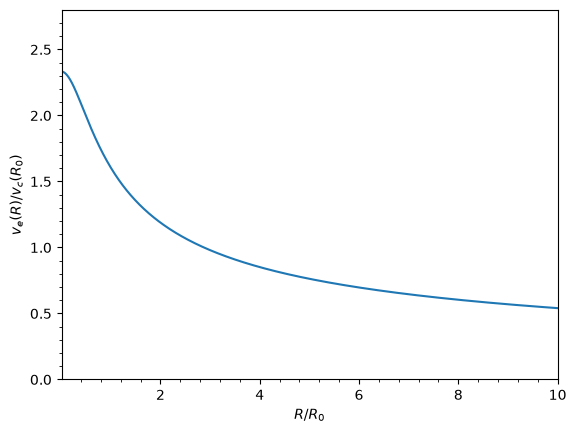

In [14]:
mp_single = MiyamotoNagaiPotential(a=0.5, b=0.0375, normalize=1.0)
mp_single.plotEscapecurve(Rrange=[0.01, 10.0], grid=1001);

We can do the same for the `MWPotential2014` composite potential:

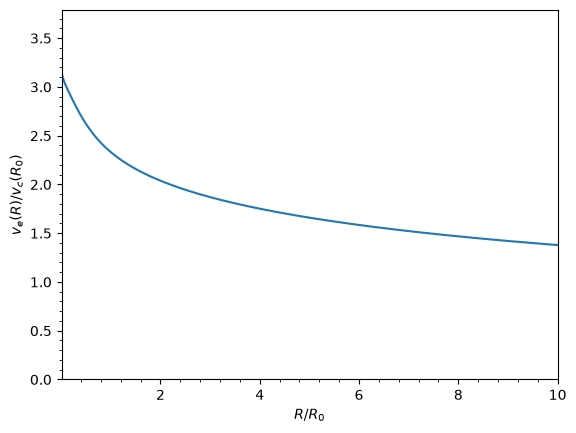

In [15]:
MWPotential2014.plotEscapecurve(Rrange=[0.01, 10.0], grid=1001);

The escape velocity at the solar radius in `MWPotential2014`:

In [16]:
v_esc = MWPotential2014.vesc(1.0)
print("Escape velocity at R=1 (natural units):", v_esc)
print("Escape velocity at solar radius:", v_esc * 220.0, "km/s")

Escape velocity at R=1 (natural units): 2.3316389848832784
Escape velocity at solar radius: 512.9605766743213 km/s


This is approximately 513 km/s, consistent with direct measurements of the
Milky Way's escape velocity (e.g., [Smith et al. 2007](http://adsabs.harvard.edu/abs/2007MNRAS.379..755S); [Piffl et al. 2014](http://adsabs.harvard.edu/abs/2014A%26A...562A..91P)).

---

## Next steps

Explore the rest of galpy's documentation:

- [Introduction to Potentials](../potentials/introduction.ipynb) — evaluate potentials, forces, densities, and orbital frequencies
- [Orbit Initialization](../orbits/initialization.ipynb) — initialize orbits from various coordinate systems
- [Milky Way-like Potentials](../potentials/milky_way_potentials.ipynb) — built-in models for the Milky Way
- [Action-Angle Coordinates](../action_angle/introduction.ipynb) — compute orbital actions, frequencies, and angles